# Minería de datos aplicada a la predicción de abandono de clientes en una empresa de telecomunicaciones

**Guía de Prácticas #01:** Minería de datos aplicada sobre un caso de estudio empresarial<br>
**Estudiante:** Leonardo Andrés Valarezo Veintimilla<br>
**Dataset:** Telco Customer Churn (IBM)

## 1. Comprensión del negocio

### 1.1 Problema

Una empresa de telecomunicaciones pierde cada mes a una parte de sus clientes, que cancelan el servicio y se pasan a la competencia. Conseguir un cliente nuevo cuesta bastante más que mantener uno que ya se tiene, así que a la empresa le conviene saber con anticipación quiénes tienen más probabilidad de irse para ofrecerles algo antes de que se vayan (un descuento, cambiar su contrato, soporte técnico, etc.).

El problema que planteo es: **¿se puede predecir, con los datos que la empresa ya tiene de cada cliente, si ese cliente va a abandonar el servicio?**

### 1.2 Objetivos específicos

1. Explorar y describir el comportamiento de los clientes de la empresa para identificar qué características se relacionan con el abandono.
2. Preparar el conjunto de datos aplicando limpieza, transformación y creación de nuevas variables para que pueda ser usado por algoritmos de minería de datos.
3. Construir y comparar tres modelos de clasificación (Regresión Logística, Árbol de Decisión y Random Forest) para predecir el abandono.
4. Evaluar los modelos con métricas de clasificación y validación cruzada para escoger el que mejor detecta a los clientes que se van.

### 1.3 Alcance

- **Variables:** 21 columnas originales con datos demográficos (género, si es adulto mayor, si tiene pareja o dependientes), servicios contratados (teléfono, internet, seguridad, streaming, etc.), datos de la cuenta (tipo de contrato, facturación, método de pago, cargo mensual, cargo total, meses de permanencia) y la variable objetivo `Abandono`.
- **Periodo de análisis:** el dataset es una fotografía de la cartera de clientes de una empresa ficticia de California creada por IBM; `Abandono` indica si el cliente se fue durante el último mes. La permanencia de los clientes va de 0 a 72 meses.
- **Contexto de aplicación:** retención de clientes en empresas de telecomunicaciones (telefonía e internet). Aunque los datos son de una empresa de ejemplo, el mismo proceso se puede llevar a cualquier operadora, incluso a las de Ecuador.

## 2. Recolección de datos

Los datos se descargan directamente desde el repositorio oficial de IBM en GitHub. Si no hay internet, el cuaderno busca el archivo en la carpeta `data/` del repositorio.

- Fuente: IBM (2019). *Telco Customer Churn*. https://github.com/IBM/telco-customer-churn-on-icp4d
- También publicado en Kaggle: https://www.kaggle.com/datasets/blastchar/telco-customer-churn

In [ ]:
import os, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix, ConfusionMatrixDisplay,
                             RocCurveDisplay, classification_report, silhouette_score)
import joblib

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

# Colores que uso en todo el cuaderno
AZUL, NARANJA, VERDE = '#2a78d6', '#eb6834', '#1baf7a'
COLORES_CHURN = {'No': AZUL, 'Sí': NARANJA}

os.makedirs('figuras', exist_ok=True)
os.makedirs('modelo', exist_ok=True)

def guardar(nombre):
    plt.tight_layout()
    plt.savefig(f'figuras/{nombre}.png', dpi=150, bbox_inches='tight')

SEMILLA = 42
print('Librerías cargadas')

Librerías cargadas


In [ ]:
URL = 'https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv'
try:
    df_original = pd.read_csv(URL)
    print('Datos descargados desde GitHub (IBM)')
except Exception:
    df_original = pd.read_csv('data/Telco-Customer-Churn.csv')
    print('Datos leídos desde la carpeta local')

df = df_original.copy()
print(f'Registros: {df.shape[0]}  |  Variables: {df.shape[1]}')
df.head()

Datos descargados desde GitHub (IBM)
Registros: 7043  |  Variables: 21


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
columnas_es = {
    'customerID': 'IDCliente', 'gender': 'Genero', 'SeniorCitizen': 'AdultoMayor', 'Partner': 'Pareja',
    'Dependents': 'Dependientes', 'tenure': 'MesesCliente', 'PhoneService': 'ServicioTelefono',
    'MultipleLines': 'VariasLineas', 'InternetService': 'ServicioInternet', 'OnlineSecurity': 'SeguridadEnLinea',
    'OnlineBackup': 'RespaldoEnLinea', 'DeviceProtection': 'ProteccionEquipo', 'TechSupport': 'SoporteTecnico',
    'StreamingTV': 'TVStreaming', 'StreamingMovies': 'PeliculasStreaming', 'Contract': 'Contrato',
    'PaperlessBilling': 'FacturaElectronica', 'PaymentMethod': 'MetodoPago', 'MonthlyCharges': 'CargoMensual',
    'TotalCharges': 'CargoTotal', 'Churn': 'Abandono'
}
valores_es = {
    'Yes': 'Sí', 'No': 'No', 'Female': 'Femenino', 'Male': 'Masculino',
    'No internet service': 'Sin servicio de internet', 'No phone service': 'Sin servicio telefónico',
    'DSL': 'DSL', 'Fiber optic': 'Fibra óptica',
    'Month-to-month': 'Mes a mes', 'One year': 'Un año', 'Two year': 'Dos años',
    'Electronic check': 'Cheque electrónico', 'Mailed check': 'Cheque por correo',
    'Bank transfer (automatic)': 'Transferencia bancaria (automática)',
    'Credit card (automatic)': 'Tarjeta de crédito (automática)'
}

df = df.rename(columns=columnas_es)
for col in df.select_dtypes(exclude='number').columns.drop(['IDCliente', 'CargoTotal']):
    df[col] = df[col].replace(valores_es)
df['AdultoMayor'] = df['AdultoMayor'].map({0: 'No', 1: 'Sí'})
df.head()

,IDCliente,Genero,AdultoMayor,Pareja,Dependientes,MesesCliente,ServicioTelefono,VariasLineas,ServicioInternet,SeguridadEnLinea,...,ProteccionEquipo,SoporteTecnico,TVStreaming,PeliculasStreaming,Contrato,FacturaElectronica,MetodoPago,CargoMensual,CargoTotal,Abandono
0,7590-VHVEG,Femenino,No,Sí,No,1,No,Sin servicio telefónico,DSL,No,...,No,No,No,No,Mes a mes,Sí,Cheque electrónico,29.85,29.85,No
1,5575-GNVDE,Masculino,No,No,No,34,Sí,No,DSL,Sí,...,Sí,No,No,No,Un año,No,Cheque por correo,56.95,1889.5,No
2,3668-QPYBK,Masculino,No,No,No,2,Sí,No,DSL,Sí,...,No,No,No,No,Mes a mes,Sí,Cheque por correo,53.85,108.15,Sí
3,7795-CFOCW,Masculino,No,No,No,45,No,Sin servicio telefónico,DSL,Sí,...,Sí,Sí,No,No,Un año,No,Transferencia bancaria (automática),42.30,1840.75,No
4,9237-HQITU,Femenino,No,No,No,2,Sí,No,Fibra óptica,No,...,No,No,No,No,Mes a mes,Sí,Cheque electrónico,70.70,151.65,Sí


## 3. Exploración de los datos

### 3.1 Estructura con `df.info()`

`info()` nos da el inventario de los datos: qué columnas hay, de qué tipo son y cuántos valores tienen. En la pirámide DIKW esto todavía es nivel de **dato**.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   IDCliente           7043 non-null   object 
 1   Genero              7043 non-null   object 
 2   AdultoMayor         7043 non-null   object 
 3   Pareja              7043 non-null   object 
 4   Dependientes        7043 non-null   object 
 5   MesesCliente        7043 non-null   int64  
 6   ServicioTelefono    7043 non-null   object 
 7   VariasLineas        7043 non-null   object 
 8   ServicioInternet    7043 non-null   object 
 9   SeguridadEnLinea    7043 non-null   object 
 10  RespaldoEnLinea     7043 non-null   object 
 11  ProteccionEquipo    7043 non-null   object 
 12  SoporteTecnico      7043 non-null   object 
 13  TVStreaming         7043 non-null   object 
 14  PeliculasStreaming  7043 non-null   object 
 15  Contrato            7043 non-null   object 
 16  Factur

Lo primero que llama la atención es que `CargoTotal` (cargo total) aparece como texto (`object`) cuando debería ser un número. Eso normalmente pasa cuando hay celdas con espacios en blanco. Lo reviso en el siguiente pasoo:

In [ ]:
blancos = (df['CargoTotal'].str.strip() == '').sum()
print('Celdas en blanco en CargoTotal:', blancos)
df[df['CargoTotal'].str.strip() == ''][['IDCliente', 'MesesCliente', 'CargoMensual', 'CargoTotal', 'Abandono']]

Celdas en blanco en CargoTotal: 11


,IDCliente,MesesCliente,CargoMensual,CargoTotal,Abandono
488,4472-LVYGI,0,52.55,,No
753,3115-CZMZD,0,20.25,,No
936,5709-LVOEQ,0,80.85,,No
1082,4367-NUYAO,0,25.75,,No
1340,1371-DWPAZ,0,56.05,,No
3331,7644-OMVMY,0,19.85,,No
3826,3213-VVOLG,0,25.35,,No
4380,2520-SGTTA,0,20.00,,No
5218,2923-ARZLG,0,19.70,,No
6670,4075-WKNIU,0,73.35,,No


Son 11 clientes y todos tienen `MesesCliente = 0`, o sea que recién firmaron y todavía no se les ha facturado nada. Por eso el cargo total está vacío. Convierto la columna a número para que esos blancos pasen a ser valores nulos (`NaN`) y así poder contarlos bien.

In [ ]:
df['CargoTotal'] = pd.to_numeric(df['CargoTotal'], errors='coerce')
print(df.dtypes.value_counts())

object     18
float64     2
int64       1
Name: count, dtype: int64


### 3.2 Valores nulos por variable

In [ ]:
nulos = pd.DataFrame({
    'nulos': df.isnull().sum(),
    'porcentaje (%)': (df.isnull().mean() * 100).round(3)
})
nulos.sort_values('nulos', ascending=False)

,nulos,porcentaje (%)
CargoTotal,11,0.156
Genero,0,0.000
AdultoMayor,0,0.000
Pareja,0,0.000
IDCliente,0,0.000
Dependientes,0,0.000
MesesCliente,0,0.000
VariasLineas,0,0.000
ServicioTelefono,0,0.000
SeguridadEnLinea,0,0.000


Solo `CargoTotal` tiene nulos: 11 de 7043 registros, que es apenas el 0,156 %. Las demás variables están completas.

### 3.3 Registros duplicados

El `IDCliente` es único para cada cliente, así que si busco duplicados con esa columna no voy a encontrar ninguno. Lo correcto es buscar filas que tengan exactamente los mismos valores en todas las demás variables.

In [ ]:
print('Duplicados contando IDCliente:', df.duplicated().sum())
cols_sin_id = df.columns.drop('IDCliente')
n_dup = df.duplicated(subset=cols_sin_id).sum()
print(f'Duplicados sin IDCliente: {n_dup}  ({n_dup / len(df) * 100:.3f} %)')
df[df.duplicated(subset=cols_sin_id, keep=False)].sort_values(['MesesCliente', 'CargoMensual']).head(6)

Duplicados contando IDCliente: 0
Duplicados sin IDCliente: 22  (0.312 %)


,IDCliente,Genero,AdultoMayor,Pareja,Dependientes,MesesCliente,ServicioTelefono,VariasLineas,ServicioInternet,SeguridadEnLinea,...,ProteccionEquipo,SoporteTecnico,TVStreaming,PeliculasStreaming,Contrato,FacturaElectronica,MetodoPago,CargoMensual,CargoTotal,Abandono
542,2866-IKBTM,Femenino,No,No,No,1,Sí,No,No,Sin servicio de internet,...,Sin servicio de internet,Sin servicio de internet,Sin servicio de internet,Sin servicio de internet,Mes a mes,No,Cheque por correo,19.55,19.55,No
1491,8605-ITULD,Femenino,No,No,No,1,Sí,No,No,Sin servicio de internet,...,Sin servicio de internet,Sin servicio de internet,Sin servicio de internet,Sin servicio de internet,Mes a mes,No,Cheque por correo,19.55,19.55,No
5170,7721-DVEKZ,Femenino,No,No,No,1,Sí,No,No,Sin servicio de internet,...,Sin servicio de internet,Sin servicio de internet,Sin servicio de internet,Sin servicio de internet,Mes a mes,No,Cheque por correo,19.65,19.65,No
6774,0970-QXPXW,Femenino,No,No,No,1,Sí,No,No,Sin servicio de internet,...,Sin servicio de internet,Sin servicio de internet,Sin servicio de internet,Sin servicio de internet,Mes a mes,No,Cheque por correo,19.65,19.65,No
4817,6654-QGBZZ,Femenino,No,No,No,1,Sí,No,No,Sin servicio de internet,...,Sin servicio de internet,Sin servicio de internet,Sin servicio de internet,Sin servicio de internet,Mes a mes,No,Cheque por correo,19.90,19.90,No
6706,7878-RTCZG,Femenino,No,No,No,1,Sí,No,No,Sin servicio de internet,...,Sin servicio de internet,Sin servicio de internet,Sin servicio de internet,Sin servicio de internet,Mes a mes,No,Cheque por correo,19.90,19.90,No


Hay 22 registros (0,312 %) que son idénticos a otro en todo menos en el ID. Casi todos son clientes de 1 mes con planes básicos, así que podrían ser personas distintas que casualmente tienen el mismo perfil. Aun así, para el modelo son información repetida que le da más peso a ese perfil, por eso los elimino en el preprocesamiento.

### 3.4 Estadística descriptiva de las variables numéricas

Aquí paso al nivel de **información**: los datos se resumen en medidas que ya dicen algo (promedio, dispersión, forma).

In [ ]:
num_cols = ['MesesCliente', 'CargoMensual', 'CargoTotal']
desc = df[num_cols].describe().T
desc['mediana'] = df[num_cols].median()
desc['rango'] = desc['max'] - desc['min']
desc['CV (%)'] = (desc['std'] / desc['mean'] * 100).round(1)
desc['asimetría'] = df[num_cols].skew()
desc['curtosis'] = df[num_cols].kurt()
desc.round(2)

,count,mean,std,min,25%,50%,75%,max,mediana,rango,CV (%),asimetría,curtosis
MesesCliente,7043.0,32.37,24.56,0.00,9.00,29.00,55.00,72.00,29.00,72.0,75.9,0.24,-1.39
CargoMensual,7043.0,64.76,30.09,18.25,35.50,70.35,89.85,118.75,70.35,100.5,46.5,-0.22,-1.26
CargoTotal,7032.0,2283.30,2266.77,18.80,401.45,1397.48,3794.74,8684.80,1397.48,8666.0,99.3,0.96,-0.23


Lo que leo de la tabla:

- **MesesCliente (meses como cliente):** promedio de 32 meses y mediana de 29. La asimetría es casi 0 (0,24), pero la curtosis es negativa (-1,39), lo que indica una distribución aplanada: hay muchos clientes nuevos y muchos muy antiguos, y no tantos en el medio.
- **CargoMensual (cargo mensual):** va de 18,25 a 118,75 dólares con promedio de 64,76. La asimetría es un poco negativa (-0,22): hay un grupo grande de clientes que paga poco (los que solo tienen teléfono).
- **CargoTotal (cargo total):** tiene asimetría positiva (0,96) y la media (2283) es bastante mayor que la mediana (1397). Esto es lógico porque el cargo total crece con los meses de permanencia y pocos clientes llevan muchos años.

In [ ]:
cat_cols = df.select_dtypes(exclude='number').columns.drop('IDCliente').tolist()
resumen_cat = pd.DataFrame({
    'categorías': df[cat_cols].nunique(),
    'más frecuente': df[cat_cols].mode().iloc[0],
    'frecuencia (%)': [round(df[c].value_counts(normalize=True).iloc[0] * 100, 1) for c in cat_cols]
})
resumen_cat

,categorías,más frecuente,frecuencia (%)
Genero,2,Masculino,50.5
AdultoMayor,2,No,83.8
Pareja,2,No,51.7
Dependientes,2,No,70.0
ServicioTelefono,2,Sí,90.3
VariasLineas,3,No,48.1
ServicioInternet,3,Fibra óptica,44.0
SeguridadEnLinea,3,No,49.7
RespaldoEnLinea,3,No,43.8
ProteccionEquipo,3,No,43.9


### 3.5 Variable objetivo: ¿cuántos clientes se van?

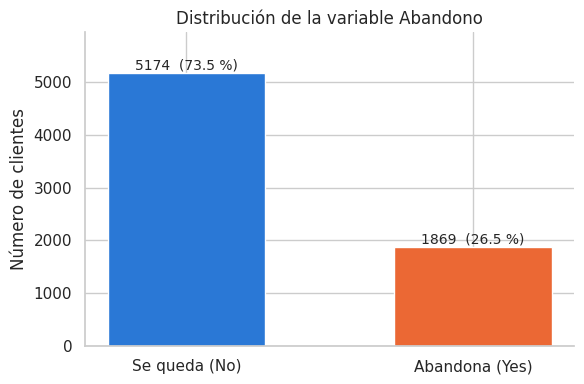

In [ ]:
conteo = df['Abandono'].value_counts()
porc = df['Abandono'].value_counts(normalize=True) * 100
fig, ax = plt.subplots(figsize=(6, 4))
barras = ax.bar(['Se queda (No)', 'Abandona (Yes)'], conteo.values, color=[AZUL, NARANJA], width=0.55)
for b, n, p in zip(barras, conteo.values, porc.values):
    ax.text(b.get_x() + b.get_width() / 2, n + 80, f'{n}  ({p:.1f} %)', ha='center', fontsize=10)
ax.set_ylabel('Número de clientes')
ax.set_title('Distribución de la variable Abandono')
ax.set_ylim(0, conteo.max() * 1.15)
guardar('01_distribucion_churn')
plt.show()

El 26,5 % de los clientes abandonó y el 73,5 % se quedó. Las clases están **desbalanceadas**, y esto es importante para después: un modelo que diga siempre "No" acertaría el 73,5 % de las veces sin servir para nada. Por eso más adelante no me voy a fijar solo en la exactitud (*accuracy*).

### 3.6 Distribución de las variables numéricas (histogramas y KDE)

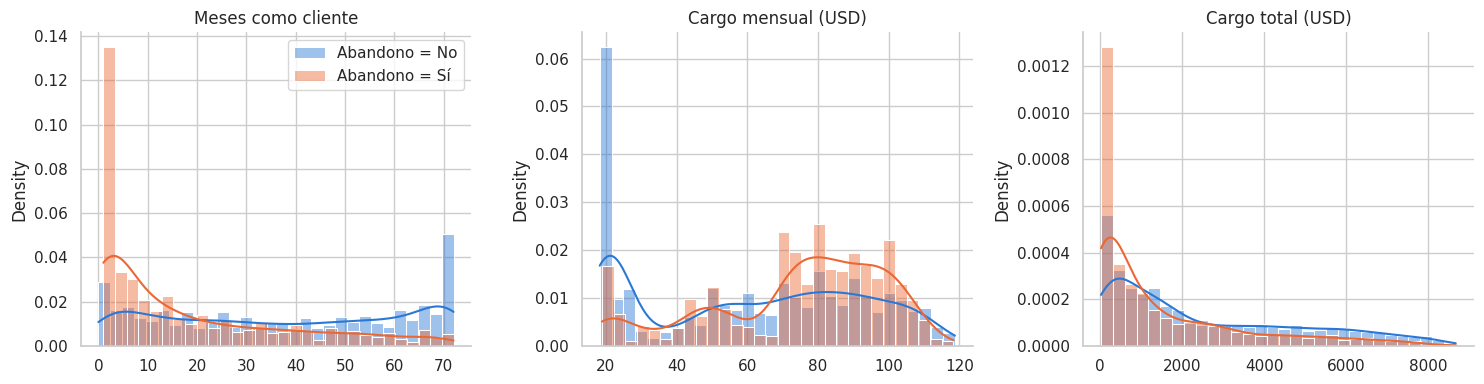

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
titulos = {'MesesCliente': 'Meses como cliente', 'CargoMensual': 'Cargo mensual (USD)', 'CargoTotal': 'Cargo total (USD)'}
for ax, col in zip(axes, num_cols):
    for clase in ['No', 'Sí']:
        sns.histplot(df[df['Abandono'] == clase][col].dropna(), bins=30, kde=True, ax=ax,
                     color=COLORES_CHURN[clase], alpha=0.45, stat='density', label=f'Abandono = {clase}')
    ax.set_title(titulos[col])
    ax.set_xlabel('')
axes[0].legend()
guardar('02_histogramas_numericas')
plt.show()

Aquí ya aparece un patrón claro. Los clientes que se van (naranja) se concentran en los **primeros meses** de permanencia, mientras que los que se quedan están repartidos y con un pico en 70 meses. En el cargo mensual, los que abandonan tienden a pagar más (entre 70 y 105 dólares). El cargo total de los que se van es bajo justamente porque se van pronto.

### 3.7 Diagramas de caja y detección de valores atípicos

Uso el método del rango intercuartílico (IQR) que vimos en la semana 4: un valor es atípico si está por debajo de Q1 − 1,5·IQR o por encima de Q3 + 1,5·IQR.

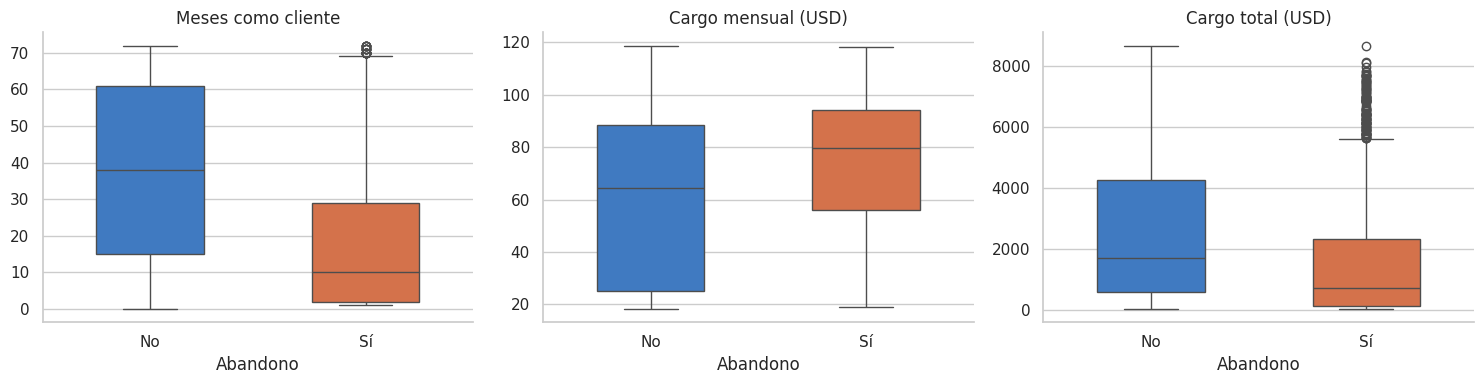

,variable,límite inferior,límite superior,atípicos,%
0,MesesCliente,-60.00,124.00,0,0.0
1,CargoMensual,-46.02,171.38,0,0.0
2,CargoTotal,-4688.48,8884.67,0,0.0


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, num_cols):
    sns.boxplot(data=df, x='Abandono', y=col, ax=ax, palette=COLORES_CHURN, width=0.5, order=['No', 'Sí'])
    ax.set_title(titulos[col])
    ax.set_ylabel('')
guardar('03_boxplots_churn')
plt.show()

def atipicos_iqr(serie):
    q1, q3 = serie.quantile([0.25, 0.75])
    iqr = q3 - q1
    li, ls = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return li, ls, ((serie < li) | (serie > ls)).sum()

filas = []
for col in num_cols:
    li, ls, n = atipicos_iqr(df[col].dropna())
    filas.append([col, round(li, 2), round(ls, 2), n, round(n / len(df) * 100, 2)])
pd.DataFrame(filas, columns=['variable', 'límite inferior', 'límite superior', 'atípicos', '%'])

Con el criterio IQR sobre toda la muestra NO HAY VALORES ATIPICOS en ninguna de las tres variables numéricas. Pero si miro el diagrama de caja de `CargoTotal` separado por grupo, sí aparecen puntos fuera de los bigotes en los clientes que abandonan: son clientes que se fueron después de muchos años y acumularon un cargo total alto. No son errores de captura, son casos reales y poco comunes, así que los dejo en el dataset. Quitarlos sería perder justamente a los clientes antiguos que también se van.

### 3.8 Tasa de abandono según las variables categóricas

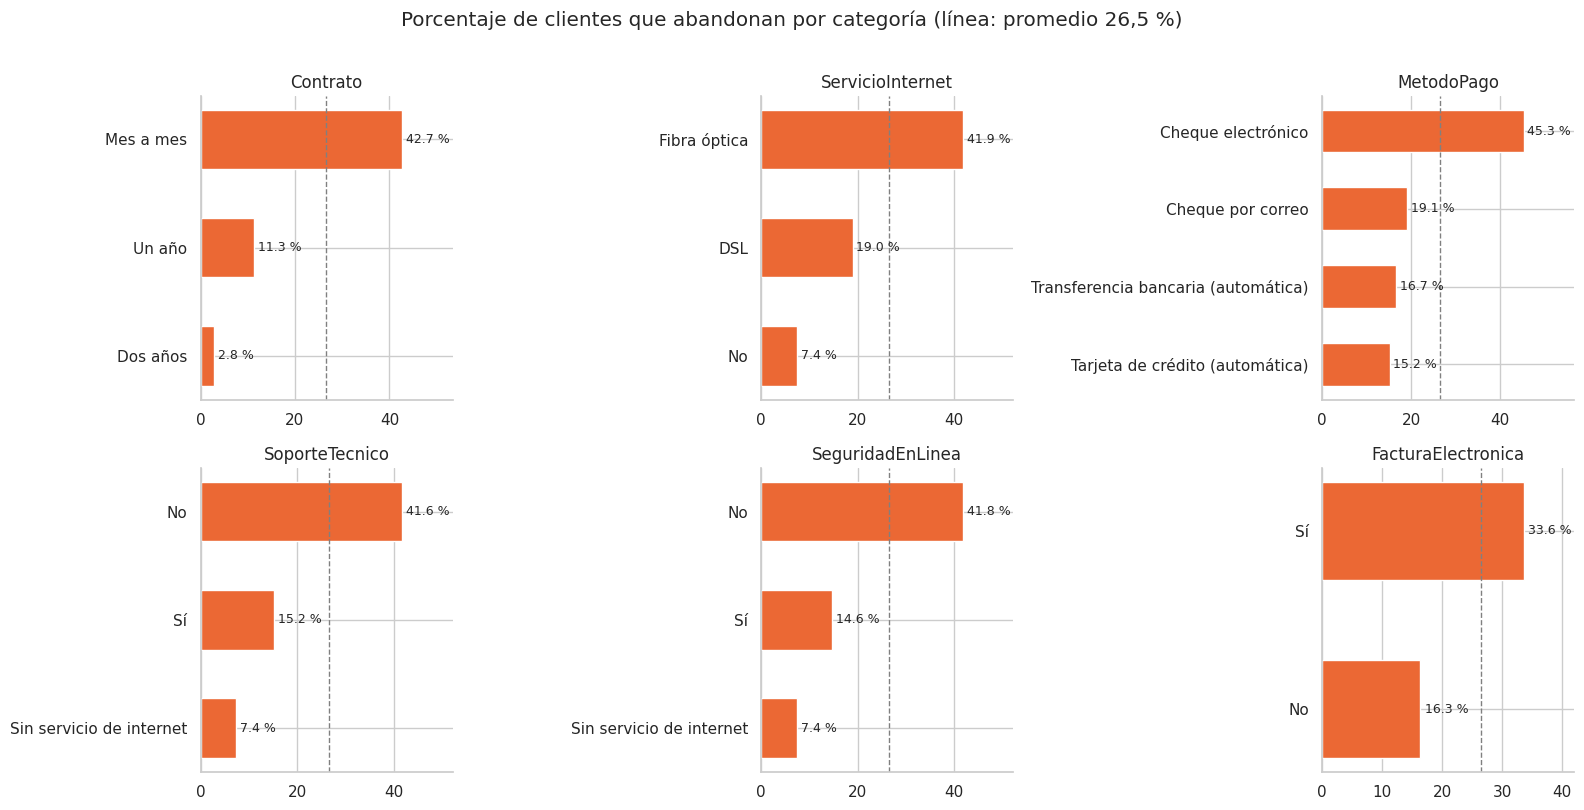

In [ ]:
variables = ['Contrato', 'ServicioInternet', 'MetodoPago', 'SoporteTecnico', 'SeguridadEnLinea', 'FacturaElectronica']
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, var in zip(axes.ravel(), variables):
    tasa = (df.groupby(var)['Abandono'].apply(lambda s: (s == 'Sí').mean() * 100)).sort_values()
    ax.barh(tasa.index, tasa.values, color=NARANJA, height=0.55)
    for i, v in enumerate(tasa.values):
        ax.text(v + 0.8, i, f'{v:.1f} %', va='center', fontsize=9)
    ax.axvline(26.5, color='gray', ls='--', lw=1)
    ax.set_title(var)
    ax.set_xlim(0, tasa.max() * 1.25)
fig.suptitle('Porcentaje de clientes que abandonan por categoría (línea: promedio 26,5 %)', y=1.01)
guardar('04_tasa_churn_categoricas')
plt.show()

Esta es probablemente la gráfica que más dice del negocio:

- **Contrato:** con contrato mes a mes se va el 42,7 % de los clientes; con contrato de dos años solo el 2,8 %.
- **Internet:** los que tienen fibra óptica abandonan mucho más (41,9 %) que los de DSL (19,0 %). Puede ser un tema de precio o de calidad del servicio.
- **Método de pago:** con cheque electrónico se va el 45,3 %, frente a un 15-19 % en los pagos automáticos.
- **Soporte técnico y seguridad en línea:** los que no los tienen abandonan más del doble.
- **Factura electrónica:** los que la usan se van más (33,6 % contra 16,3 %).

### 3.9 Variables demográficas (countplot)

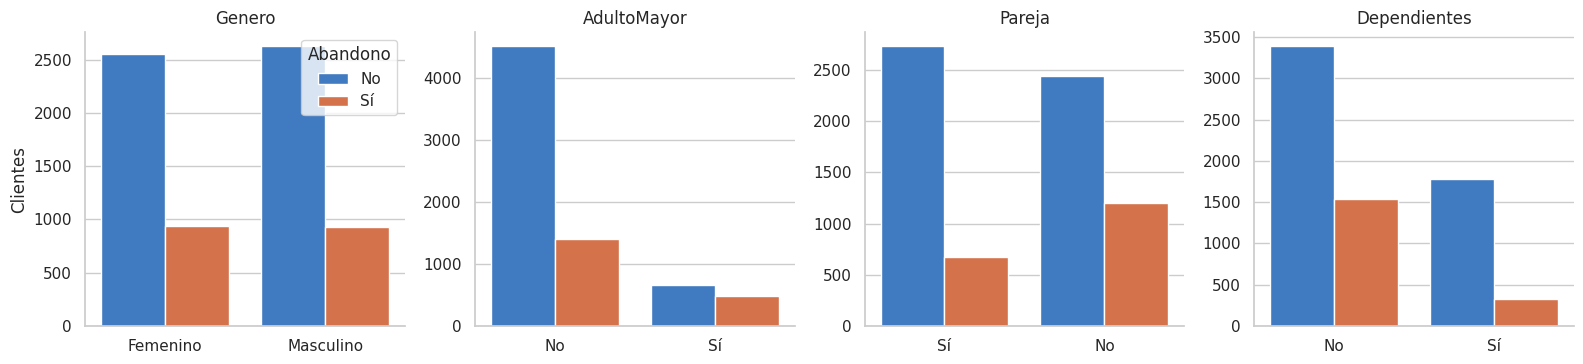

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(16, 3.8))
for ax, var in zip(axes, ['Genero', 'AdultoMayor', 'Pareja', 'Dependientes']):
    sns.countplot(data=df, x=var, hue='Abandono', palette=COLORES_CHURN, ax=ax, hue_order=['No', 'Sí'])
    ax.set_title(var)
    ax.set_xlabel('')
    ax.set_ylabel('Clientes' if var == 'Genero' else '')
    if var != 'Genero':
        ax.get_legend().remove()
guardar('05_demograficas')
plt.show()

El género prácticamente no influye (las barras son casi iguales). En cambio, los adultos mayores, los que no tienen pareja y los que no tienen dependientes abandonan en mayor proporción.

### 3.10 Correlación entre variables numéricas

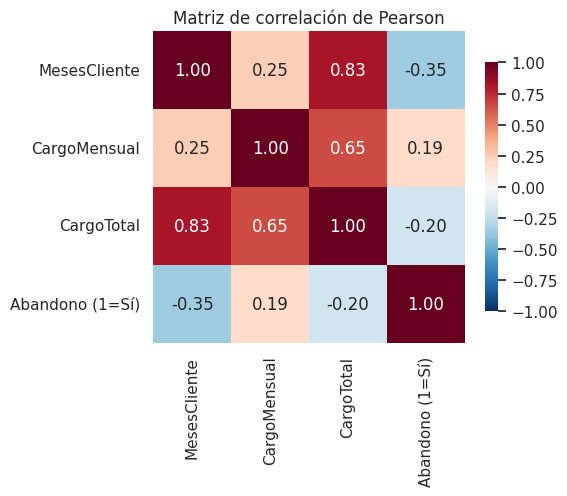

In [ ]:
tmp = df[num_cols].copy()
tmp['Abandono (1=Sí)'] = (df['Abandono'] == 'Sí').astype(int)
corr = tmp.corr()
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', vmin=-1, vmax=1, ax=ax, square=True,
            cbar_kws={'shrink': 0.8})
ax.set_title('Matriz de correlación de Pearson')
guardar('06_correlacion')
plt.show()

`CargoTotal` tiene una correlación muy alta con `MesesCliente` (0,83), algo esperable porque el total es más o menos el cargo mensual por los meses. Con respecto al abandono, `MesesCliente` tiene correlación negativa (-0,35): mientras más tiempo lleva el cliente, menos probable es que se vaya. `CargoMensual` tiene correlación positiva (0,19): quien paga más, se va un poco más.

## 4. Preprocesamiento de datos

### 4.1 Tratamiento de valores nulos

Los 11 nulos de `CargoTotal` son clientes con `MesesCliente = 0`. No tiene sentido imputarlos con la media o la mediana (serían más de 1000 dólares para alguien que no ha pagado nada), así que les pongo **0**, que es el valor real de lo que han pagado hasta ahora.

In [ ]:
print('Nulos antes:', df['CargoTotal'].isnull().sum())
df['CargoTotal'] = df['CargoTotal'].fillna(0)
print('Nulos después:', df['CargoTotal'].isnull().sum())

Nulos antes: 11
Nulos después: 0


### 4.2 Eliminación de duplicados

In [ ]:
antes = len(df)
df = df.drop_duplicates(subset=cols_sin_id, keep='first').reset_index(drop=True)
print(f'Registros antes: {antes}  |  eliminados: {antes - len(df)}  |  quedan: {len(df)}')

Registros antes: 7043  |  eliminados: 22  |  quedan: 7021


### 4.3 Limpieza de categorías

En seis columnas de servicios aparece la categoría "Sin servicio de internet", y en `VariasLineas` aparece "Sin servicio telefónico". En la práctica significan lo mismo que "No" (el cliente no tiene ese servicio) y la información de si tiene internet o teléfono ya está en `ServicioInternet` y `ServicioTelefono`. Las unifico para no tener columnas repetidas al codificar.

In [ ]:
servicios_internet = ['SeguridadEnLinea', 'RespaldoEnLinea', 'ProteccionEquipo', 'SoporteTecnico', 'TVStreaming', 'PeliculasStreaming']
for c in servicios_internet:
    df[c] = df[c].replace('Sin servicio de internet', 'No')
df['VariasLineas'] = df['VariasLineas'].replace('Sin servicio telefónico', 'No')
df[servicios_internet + ['VariasLineas']].apply(lambda s: s.unique())

,SeguridadEnLinea,RespaldoEnLinea,ProteccionEquipo,SoporteTecnico,TVStreaming,PeliculasStreaming,VariasLineas
0,No,Sí,No,No,No,No,No
1,Sí,No,Sí,Sí,Sí,Sí,Sí


### 4.4 Ingeniería de variables (*feature engineering*)

Creo tres variables nuevas que tienen sentido para el negocio:

1. **`NumServicios`**: cuántos servicios adicionales tiene contratados el cliente (de 0 a 8). La idea es que un cliente con más servicios está más "amarrado" a la empresa.
2. **`CargoPromedioMensual`**: `CargoTotal / MesesCliente`. Es lo que en realidad ha pagado en promedio por mes. Para los clientes con 0 meses uso el cargo mensual.
3. **`GrupoAntiguedad`**: la permanencia en rangos (0-12, 13-24, 25-48 y más de 48 meses), porque en el histograma se vio que el primer año es el más crítico.

In [ ]:
def crear_variables(d):
    d = d.copy()
    servicios = ['ServicioTelefono', 'VariasLineas', 'SeguridadEnLinea', 'RespaldoEnLinea',
                 'ProteccionEquipo', 'SoporteTecnico', 'TVStreaming', 'PeliculasStreaming']
    d['NumServicios'] = (d[servicios] == 'Sí').sum(axis=1)
    d['CargoPromedioMensual'] = np.where(d['MesesCliente'] > 0, d['CargoTotal'] / d['MesesCliente'].replace(0, 1), d['CargoMensual'])
    d['GrupoAntiguedad'] = pd.cut(d['MesesCliente'], bins=[-1, 12, 24, 48, 100],
                                  labels=['0-12', '13-24', '25-48', '49-72']).astype(str)
    return d

df = crear_variables(df)
df[['MesesCliente', 'CargoMensual', 'CargoTotal', 'NumServicios', 'CargoPromedioMensual', 'GrupoAntiguedad']].head()

,MesesCliente,CargoMensual,CargoTotal,NumServicios,CargoPromedioMensual,GrupoAntiguedad
0,1,29.85,29.85,1,29.850000,0-12
1,34,56.95,1889.50,3,55.573529,25-48
2,2,53.85,108.15,3,54.075000,0-12
3,45,42.30,1840.75,3,40.905556,25-48
4,2,70.70,151.65,1,75.825000,0-12


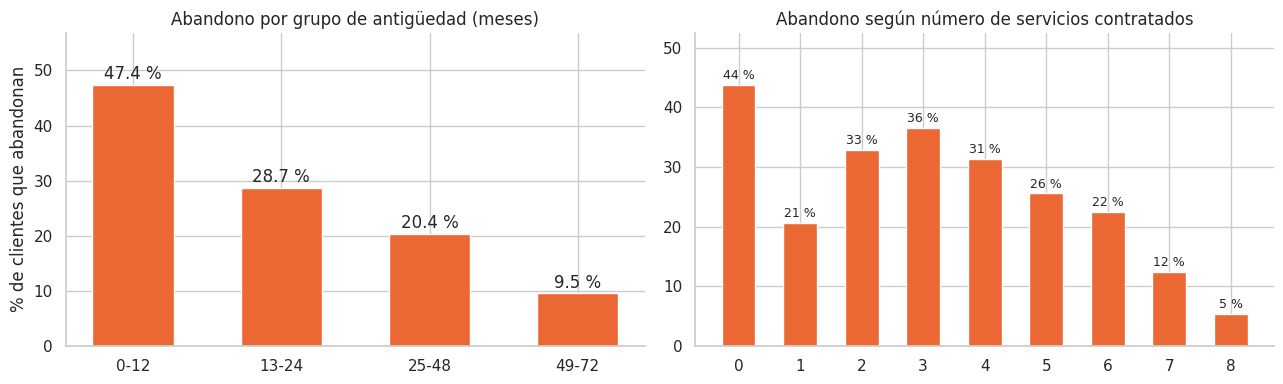

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
t1 = df.groupby('GrupoAntiguedad')['Abandono'].apply(lambda s: (s == 'Sí').mean() * 100)
axes[0].bar(t1.index, t1.values, color=NARANJA, width=0.55)
for i, v in enumerate(t1.values):
    axes[0].text(i, v + 1, f'{v:.1f} %', ha='center')
axes[0].set_title('Abandono por grupo de antigüedad (meses)')
axes[0].set_ylabel('% de clientes que abandonan')
axes[0].set_ylim(0, t1.max() * 1.2)

t2 = df.groupby('NumServicios')['Abandono'].apply(lambda s: (s == 'Sí').mean() * 100)
axes[1].bar(t2.index.astype(str), t2.values, color=NARANJA, width=0.55)
for i, v in enumerate(t2.values):
    axes[1].text(i, v + 1, f'{v:.0f} %', ha='center', fontsize=9)
axes[1].set_title('Abandono según número de servicios contratados')
axes[1].set_ylim(0, t2.max() * 1.2)
guardar('07_variables_derivadas')
plt.show()

Las variables nuevas sí aportan. En el primer año se va casi la mitad de los clientes (47,4 %), mientras que después de 4 años solo se va el 9,5 %. Con el número de servicios el comportamiento no es lineal: los clientes con un solo servicio tienen un abandono bajo (20,7 %, son en su mayoría los que solo tienen teléfono y pagan poco), pero desde 3 servicios en adelante, mientras más servicios tienen, menos se van: se pasa de 36,5 % con 3 servicios a solo 5,3 % con los 8.

### 4.5 Codificación y normalización

- La variable objetivo `Abandono` pasa a 1 (abandona) y 0 (se queda).
- Las variables categóricas se codifican con **One-Hot Encoding** (una columna 0/1 por categoría). Uso `drop='if_binary'` para que las variables de solo dos valores (Sí/No) queden en una sola columna.
- Las variables numéricas se normalizan con **StandardScaler** (media 0 y desviación 1). Esto lo necesita la Regresión Logística y también el PCA y K-Means; a los árboles no les afecta.

Todo esto lo meto en un `ColumnTransformer` dentro de un `Pipeline`, así la misma transformación se aplica igual al entrenar, al probar y al usar el modelo con clientes nuevos.

In [ ]:
y = (df['Abandono'] == 'Sí').astype(int)
X = df.drop(columns=['IDCliente', 'Abandono'])

numericas = ['MesesCliente', 'CargoMensual', 'CargoTotal', 'NumServicios', 'CargoPromedioMensual']
categoricas = [c for c in X.columns if c not in numericas]

preprocesador = ColumnTransformer([
    ('num', StandardScaler(), numericas),
    ('cat', OneHotEncoder(drop='if_binary', handle_unknown='ignore'), categoricas)
])

X_transformado = preprocesador.fit_transform(X)
nombres = preprocesador.get_feature_names_out()
print('Variables numéricas:', len(numericas), '| categóricas:', len(categoricas))
print('Columnas después de codificar:', X_transformado.shape[1])
pd.DataFrame(X_transformado[:3], columns=nombres).round(2)

Variables numéricas: 5 | categóricas: 17
Columnas después de codificar: 32


,num__MesesCliente,num__CargoMensual,num__CargoTotal,num__NumServicios,num__CargoPromedioMensual,cat__Genero_Masculino,cat__AdultoMayor_Sí,cat__Pareja_Sí,cat__Dependientes_Sí,cat__ServicioTelefono_Sí,...,cat__Contrato_Un año,cat__FacturaElectronica_Sí,cat__MetodoPago_Cheque electrónico,cat__MetodoPago_Cheque por correo,cat__MetodoPago_Tarjeta de crédito (automática),cat__MetodoPago_Transferencia bancaria (automática),cat__GrupoAntiguedad_0-12,cat__GrupoAntiguedad_13-24,cat__GrupoAntiguedad_25-48,cat__GrupoAntiguedad_49-72
0,-1.28,-1.16,-1.00,-1.15,-1.16,0.0,0.0,1.0,0.0,0.0,...,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,0.06,-0.26,-0.18,-0.18,-0.31,1.0,0.0,0.0,0.0,1.0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
2,-1.24,-0.37,-0.96,-0.18,-0.36,1.0,0.0,0.0,0.0,1.0,...,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0


## 5. Análisis descriptivo: reducción de dimensionalidad y segmentación

Antes de los modelos predictivos aplico dos técnicas descriptivas (no supervisadas) para entender cómo se agrupan los clientes.

### 5.1 PCA (Análisis de Componentes Principales)

Después de codificar tengo 32 columnas. Con PCA reviso cuántas componentes hacen falta para explicar la mayor parte de la variabilidad y proyecto los clientes en 2 dimensiones para verlos.

PC1 explica 43.3 %  |  PC1+PC2: 59.6 %
Componentes para 80 %: 10  |  para 90 %: 15


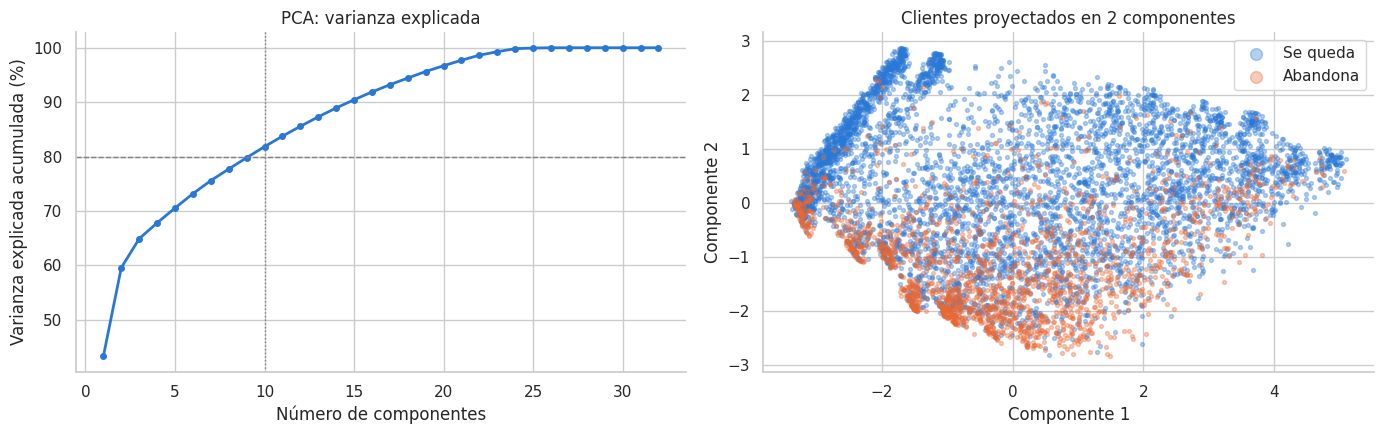

In [ ]:
pca = PCA(random_state=SEMILLA)
pca.fit(X_transformado)
var_acum = np.cumsum(pca.explained_variance_ratio_) * 100
n80 = int(np.argmax(var_acum >= 80) + 1)
n90 = int(np.argmax(var_acum >= 90) + 1)
print(f'PC1 explica {pca.explained_variance_ratio_[0]*100:.1f} %  |  PC1+PC2: {var_acum[1]:.1f} %')
print(f'Componentes para 80 %: {n80}  |  para 90 %: {n90}')

pca2 = PCA(n_components=2, random_state=SEMILLA)
Z = pca2.fit_transform(X_transformado)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
axes[0].plot(range(1, len(var_acum) + 1), var_acum, marker='o', ms=4, color=AZUL, lw=2)
axes[0].axhline(80, color='gray', ls='--', lw=1)
axes[0].axvline(n80, color='gray', ls=':', lw=1)
axes[0].set_xlabel('Número de componentes')
axes[0].set_ylabel('Varianza explicada acumulada (%)')
axes[0].set_title('PCA: varianza explicada')
for clase, color, nombre in [(0, AZUL, 'Se queda'), (1, NARANJA, 'Abandona')]:
    m = y.values == clase
    axes[1].scatter(Z[m, 0], Z[m, 1], s=8, alpha=0.35, color=color, label=nombre)
axes[1].set_xlabel('Componente 1')
axes[1].set_ylabel('Componente 2')
axes[1].set_title('Clientes proyectados en 2 componentes')
axes[1].legend(markerscale=3)
guardar('08_pca')
plt.show()

La primera componente explica el 43,3 % de la variabilidad y las dos primeras juntas el 59,6 %; para llegar al 80 % hacen falta 10 componentes de 32. En la proyección se ve que los clientes que abandonan (naranja) se concentran hacia un lado del gráfico, aunque se mezclan con los que se quedan. Esto me dice que el abandono sí tiene un patrón, pero que no se separa con una línea simple; por eso tiene sentido probar modelos no lineales como los árboles.

### 5.2 Segmentación de clientes con K-Means

Uso K-Means sobre las variables normalizadas para ver si existen grupos naturales de clientes. Para elegir el número de grupos (k) uso el método del codo y el coeficiente de silueta.

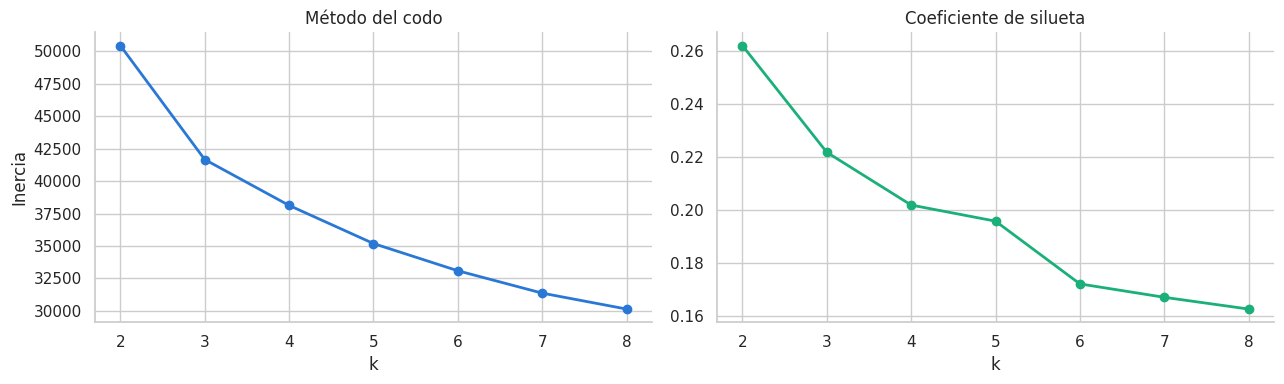

             0      1      2      3      4      5      6
k        2.000  3.000  4.000  5.000  6.000  7.000  8.000
silueta  0.262  0.222  0.202  0.196  0.172  0.167  0.163


In [ ]:
ks = range(2, 9)
inercias, siluetas = [], []
muestra = np.random.RandomState(SEMILLA).choice(len(X_transformado), 3000, replace=False)
for k in ks:
    km = KMeans(n_clusters=k, n_init=10, random_state=SEMILLA).fit(X_transformado)
    inercias.append(km.inertia_)
    siluetas.append(silhouette_score(X_transformado[muestra], km.labels_[muestra]))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(list(ks), inercias, marker='o', color=AZUL, lw=2)
axes[0].set_title('Método del codo')
axes[0].set_xlabel('k')
axes[0].set_ylabel('Inercia')
axes[1].plot(list(ks), siluetas, marker='o', color=VERDE, lw=2)
axes[1].set_title('Coeficiente de silueta')
axes[1].set_xlabel('k')
guardar('09_kmeans_k')
plt.show()
print(pd.DataFrame({'k': list(ks), 'silueta': np.round(siluetas, 3)}).T)

In [ ]:
K = 3
kmeans = KMeans(n_clusters=K, n_init=10, random_state=SEMILLA).fit(X_transformado)
df['Segmento'] = kmeans.labels_

perfil = df.groupby('Segmento').agg(
    clientes=('MesesCliente', 'size'),
    meses_promedio=('MesesCliente', 'mean'),
    cargo_mensual=('CargoMensual', 'mean'),
    servicios=('NumServicios', 'mean'),
    fibra_pct=('ServicioInternet', lambda s: (s == 'Fibra óptica').mean() * 100),
    mes_a_mes_pct=('Contrato', lambda s: (s == 'Mes a mes').mean() * 100),
    abandono_pct=('Abandono', lambda s: (s == 'Sí').mean() * 100),
).round(1)
perfil

,clientes,meses_promedio,cargo_mensual,servicios,fibra_pct,mes_a_mes_pct,abandono_pct
Segmento,,,,,,,
0,2566,16.1,77.4,3.3,69.9,88.5,47.1
1,2357,26.9,28.4,1.4,0.0,47.8,15.0
2,2098,58.7,90.4,5.7,61.8,21.7,14.1


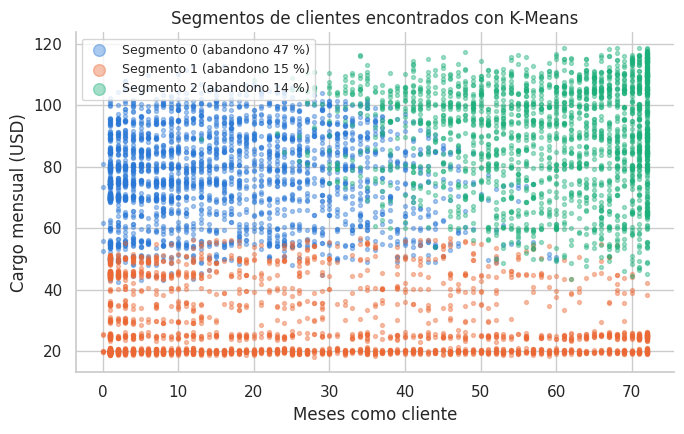

In [ ]:
fig, ax = plt.subplots(figsize=(7, 4.5))
for seg, color in zip(range(K), [AZUL, NARANJA, VERDE]):
    m = df['Segmento'] == seg
    ax.scatter(df.loc[m, 'MesesCliente'], df.loc[m, 'CargoMensual'], s=8, alpha=0.4, color=color,
               label=f'Segmento {seg} (abandono {perfil.loc[seg, "abandono_pct"]:.0f} %)')
ax.set_xlabel('Meses como cliente')
ax.set_ylabel('Cargo mensual (USD)')
ax.set_title('Segmentos de clientes encontrados con K-Means')
ax.legend(markerscale=3, fontsize=9)
guardar('10_segmentos_kmeans')
plt.show()

La silueta más alta sale con k = 2 (0,262), pero con dos grupos solo se separa a los que tienen internet de los que no, y eso ya lo sabía. Con **k = 3** la silueta baja un poco (0,222), el codo empieza a suavizarse y los grupos tienen más sentido para el negocio:

- **Segmento 0 (2566 clientes):** clientes nuevos (16 meses en promedio), 88,5 % con contrato mes a mes y 69,9 % con fibra óptica. Su abandono es de **47,1 %**, casi el doble del promedio.
- **Segmento 1 (2357 clientes):** clientes sin internet o con planes básicos, pagan unos 28 dólares al mes. Abandono de 15,0 %.
- **Segmento 2 (2098 clientes):** clientes antiguos (59 meses), con muchos servicios y cargos altos (90 dólares). Abandono de 14,1 %.

El segmento 0 es al que la empresa debería apuntar primero con sus campañas de retención.

La columna `Segmento` solo la uso para describir; no la meto en los modelos predictivos.

## 6. Modelado predictivo

### 6.1 División en entrenamiento y prueba

Separo **80 % para entrenamiento y 20 % para prueba**, de forma estratificada para que las dos partes mantengan la misma proporción de clientes que abandonan (26,5 %). Uso una semilla fija (42) para que los resultados se puedan repetir.

In [ ]:
X = X.drop(columns=['Segmento'], errors='ignore')
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, stratify=y, random_state=SEMILLA)
print(f'Entrenamiento: {len(X_train)} registros  ({y_train.mean()*100:.1f} % abandono)')
print(f'Prueba:        {len(X_test)} registros  ({y_test.mean()*100:.1f} % abandono)')

Entrenamiento: 5616 registros  (26.4 % abandono)
Prueba:        1405 registros  (26.5 % abandono)


### 6.2 Modelos y parámetros

Pruebo tres técnicas de clasificación distintas. En las tres uso `class_weight='balanced'`, que le da más peso a la clase minoritaria (los que abandonan) para compensar el desbalance.

| Modelo | Parámetros principales | Por qué lo elegí |
|---|---|---|
| Regresión Logística | `C=1.0`, `max_iter=1000`, `class_weight='balanced'` | Es el modelo base en churn y crédito (semana 13). Da probabilidades y sus coeficientes se pueden interpretar. |
| Árbol de Decisión | `max_depth=5`, `min_samples_leaf=30`, `criterion='gini'`, `class_weight='balanced'` | Es el modelo que estudiamos en la unidad 3. Genera reglas fáciles de explicar a la gerencia. Limito la profundidad para evitar el sobreajuste. |
| Random Forest | `n_estimators=300`, `max_depth=8`, `min_samples_leaf=10`, `class_weight='balanced'` | Es un conjunto de muchos árboles; normalmente es más estable y preciso que un solo árbol. |

In [ ]:
modelos = {
    'Regresión Logística': LogisticRegression(C=1.0, max_iter=1000, class_weight='balanced', random_state=SEMILLA),
    'Árbol de Decisión': DecisionTreeClassifier(max_depth=5, min_samples_leaf=30, criterion='gini',
                                                class_weight='balanced', random_state=SEMILLA),
    'Random Forest': RandomForestClassifier(n_estimators=300, max_depth=8, min_samples_leaf=10,
                                            class_weight='balanced', random_state=SEMILLA, n_jobs=-1),
}

pipelines = {}
for nombre, modelo in modelos.items():
    pipe = Pipeline([('prep', preprocesador), ('modelo', modelo)])
    pipe.fit(X_train, y_train)
    pipelines[nombre] = pipe
    print(f'{nombre}: entrenado')

Regresión Logística: entrenado
Árbol de Decisión: entrenado
Random Forest: entrenado


## 7. Evaluación y validación

### 7.1 Métricas en el conjunto de prueba

Como el problema es de clasificación con clases desbalanceadas, uso las métricas de la semana 12:

- **Accuracy:** $\frac{TP+TN}{TP+TN+FP+FN}$, porcentaje total de aciertos.
- **Precision:** $\frac{TP}{TP+FP}$, de los que el modelo dice que se van, cuántos se van de verdad.
- **Recall (sensibilidad):** $\frac{TP}{TP+FN}$, de los que realmente se van, cuántos detecta el modelo.
- **F1:** $2 \cdot \frac{Precision \cdot Recall}{Precision + Recall}$, equilibrio entre las dos anteriores.
- **AUC-ROC:** área bajo la curva ROC; 0,5 es adivinar al azar y 1 es perfecto.

Para este negocio la métrica más importante es el **recall**: dejar pasar a un cliente que se va (falso negativo) le cuesta a la empresa el cliente completo, mientras que una falsa alarma (falso positivo) solo cuesta un descuento o una llamada.

In [ ]:
filas = []
for nombre, pipe in pipelines.items():
    pred = pipe.predict(X_test)
    prob = pipe.predict_proba(X_test)[:, 1]
    filas.append({
        'Modelo': nombre,
        'Accuracy': accuracy_score(y_test, pred),
        'Precision': precision_score(y_test, pred),
        'Recall': recall_score(y_test, pred),
        'F1': f1_score(y_test, pred),
        'AUC-ROC': roc_auc_score(y_test, prob),
    })
tabla_prueba = pd.DataFrame(filas).set_index('Modelo').round(4)
tabla_prueba

,Accuracy,Precision,Recall,F1,AUC-ROC
Modelo,,,,,
Regresión Logística,0.7374,0.5026,0.7742,0.6095,0.8400
Árbol de Decisión,0.7452,0.5127,0.7608,0.6126,0.8314
Random Forest,0.7601,0.5327,0.7661,0.6284,0.8434


### 7.2 Matrices de confusión

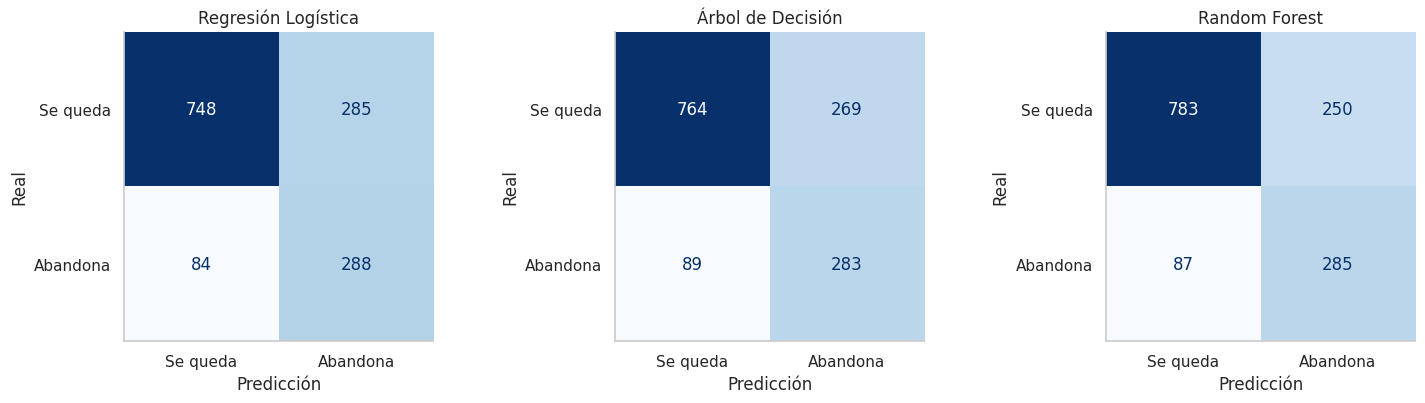

Regresión Logística    TP= 288  FN=  84  FP= 285  TN= 748
Árbol de Decisión      TP= 283  FN=  89  FP= 269  TN= 764
Random Forest          TP= 285  FN=  87  FP= 250  TN= 783


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
for ax, (nombre, pipe) in zip(axes, pipelines.items()):
    cm = confusion_matrix(y_test, pipe.predict(X_test))
    ConfusionMatrixDisplay(cm, display_labels=['Se queda', 'Abandona']).plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(nombre)
    ax.set_xlabel('Predicción')
    ax.set_ylabel('Real')
    ax.grid(False)
guardar('11_matrices_confusion')
plt.show()

for nombre, pipe in pipelines.items():
    tn, fp, fn, tp = confusion_matrix(y_test, pipe.predict(X_test)).ravel()
    print(f'{nombre:22s} TP={tp:4d}  FN={fn:4d}  FP={fp:4d}  TN={tn:4d}')

### 7.3 Curvas ROC

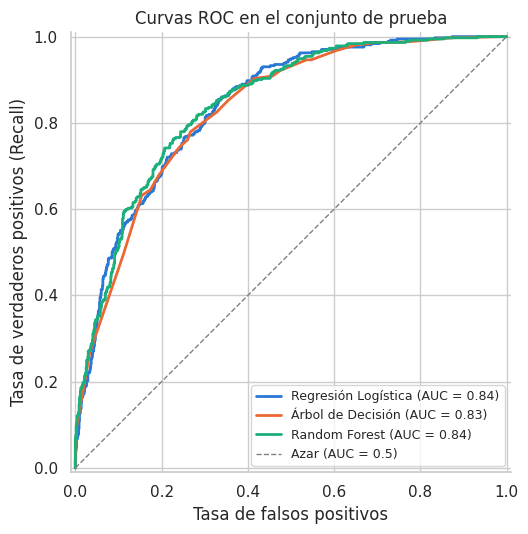

In [ ]:
fig, ax = plt.subplots(figsize=(6.5, 5.5))
for (nombre, pipe), color in zip(pipelines.items(), [AZUL, NARANJA, VERDE]):
    RocCurveDisplay.from_estimator(pipe, X_test, y_test, ax=ax, name=nombre, color=color, lw=2)
ax.plot([0, 1], [0, 1], ls='--', color='gray', lw=1, label='Azar (AUC = 0.5)')
ax.set_title('Curvas ROC en el conjunto de prueba')
ax.set_xlabel('Tasa de falsos positivos')
ax.set_ylabel('Tasa de verdaderos positivos (Recall)')
ax.legend(loc='lower right', fontsize=9)
guardar('12_curvas_roc')
plt.show()

### 7.4 Validación cruzada (k = 5)

Una sola división entrenamiento/prueba puede salir "con suerte". Para confirmar los resultados aplico **validación cruzada estratificada con 5 particiones** (5 *folds*) sobre el conjunto de entrenamiento: el modelo se entrena 5 veces con 4 partes y se evalúa con la parte restante, y al final se promedian los resultados.

In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEMILLA)
metricas = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
resultados_cv = {}
filas = []
for nombre, modelo in modelos.items():
    pipe = Pipeline([('prep', preprocesador), ('modelo', modelo)])
    r = cross_validate(pipe, X_train, y_train, cv=cv, scoring=metricas, n_jobs=-1)
    resultados_cv[nombre] = r
    fila = {'Modelo': nombre}
    for m in metricas:
        fila[m] = f"{r['test_' + m].mean():.4f} ± {r['test_' + m].std():.4f}"
    filas.append(fila)
tabla_cv = pd.DataFrame(filas).set_index('Modelo')
tabla_cv.columns = ['Accuracy', 'Precision', 'Recall', 'F1', 'AUC-ROC']
tabla_cv

,Accuracy,Precision,Recall,F1,AUC-ROC
Modelo,,,,,
Regresión Logística,0.7482 ± 0.0141,0.5153 ± 0.0170,0.8034 ± 0.0316,0.6278 ± 0.0216,0.8462 ± 0.0175
Árbol de Decisión,0.7455 ± 0.0201,0.5130 ± 0.0248,0.8013 ± 0.0283,0.6251 ± 0.0227,0.8326 ± 0.0197
Random Forest,0.7648 ± 0.0111,0.5379 ± 0.0147,0.7879 ± 0.0270,0.6391 ± 0.0165,0.8481 ± 0.0180


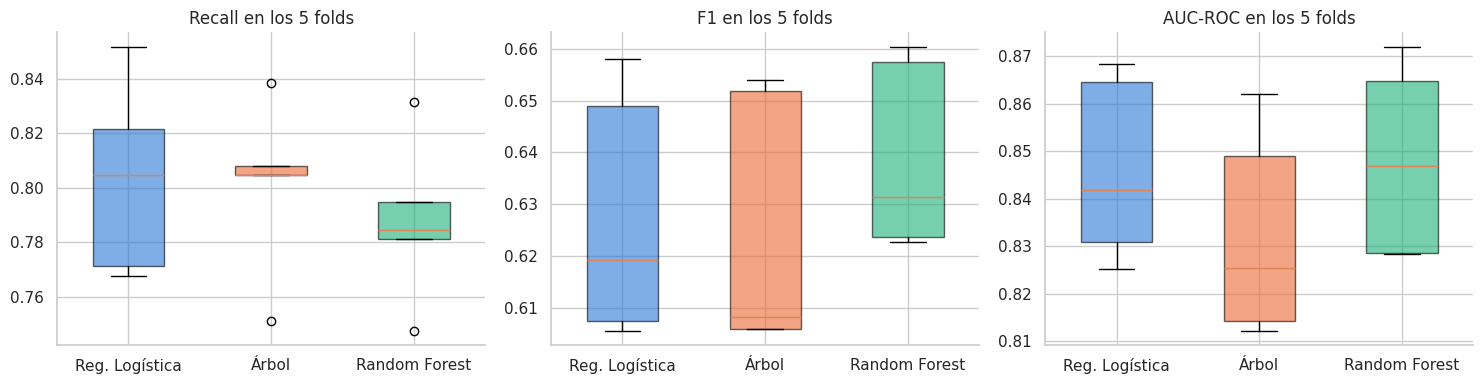

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, m, titulo in zip(axes, ['recall', 'f1', 'roc_auc'], ['Recall', 'F1', 'AUC-ROC']):
    datos = [resultados_cv[n]['test_' + m] for n in modelos]
    bp = ax.boxplot(datos, patch_artist=True, widths=0.5)
    for patch, color in zip(bp['boxes'], [AZUL, NARANJA, VERDE]):
        patch.set_facecolor(color)
        patch.set_alpha(0.6)
    ax.set_xticks([1, 2, 3])
    ax.set_xticklabels(['Reg. Logística', 'Árbol', 'Random Forest'])
    ax.set_title(f'{titulo} en los 5 folds')
guardar('13_validacion_cruzada')
plt.show()

### 7.5 Comparación final

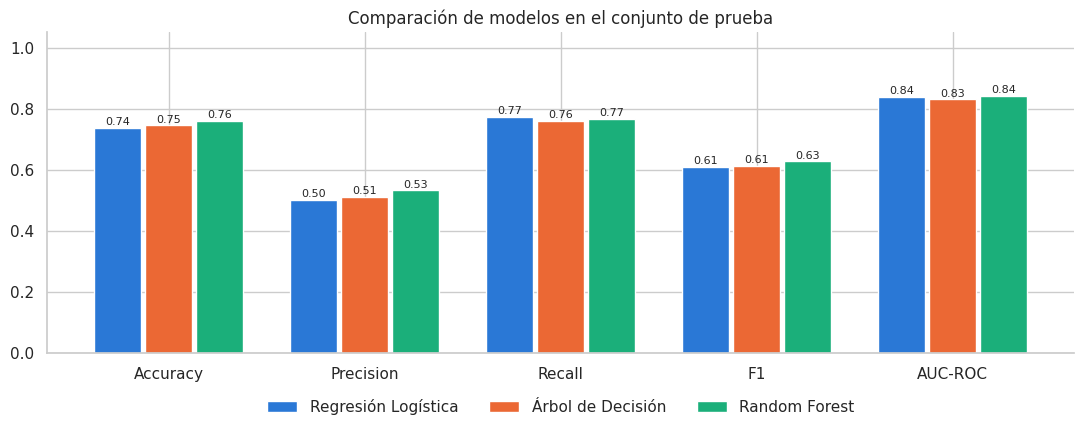

In [ ]:
comp = tabla_prueba[['Accuracy', 'Precision', 'Recall', 'F1', 'AUC-ROC']]
fig, ax = plt.subplots(figsize=(11, 4.5))
x = np.arange(len(comp.columns))
ancho = 0.26
for i, (nombre, color) in enumerate(zip(comp.index, [AZUL, NARANJA, VERDE])):
    barras = ax.bar(x + (i - 1) * ancho, comp.loc[nombre].values, ancho - 0.02, color=color, label=nombre)
    for b in barras:
        ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 0.01, f'{b.get_height():.2f}',
                ha='center', fontsize=8)
ax.set_xticks(x)
ax.set_xticklabels(comp.columns)
ax.set_ylim(0, 1.05)
ax.set_title('Comparación de modelos en el conjunto de prueba')
ax.legend(loc='upper center', ncol=3, bbox_to_anchor=(0.5, -0.1), frameon=False)
guardar('14_comparacion_modelos')
plt.show()

### 7.6 Interpretación de los modelos

Además de saber qué tan bien predicen, me interesa saber qué variables usan para decidir, porq eso es lo que se convierte en conocimiento para la empresa.

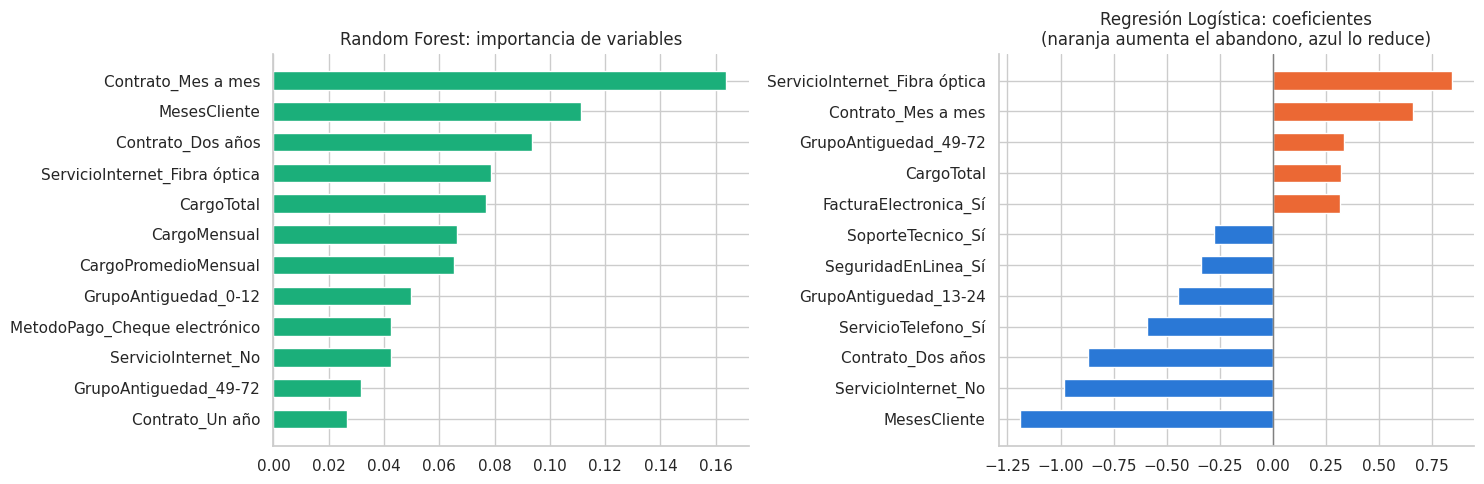

In [ ]:
rf = pipelines['Random Forest']
imp = pd.Series(rf.named_steps['modelo'].feature_importances_,
                index=rf.named_steps['prep'].get_feature_names_out())
imp.index = imp.index.str.replace('num__', '').str.replace('cat__', '')
top = imp.sort_values(ascending=True).tail(12)

lr = pipelines['Regresión Logística']
coef = pd.Series(lr.named_steps['modelo'].coef_[0], index=lr.named_steps['prep'].get_feature_names_out())
coef.index = coef.index.str.replace('num__', '').str.replace('cat__', '')
coef_top = coef.reindex(coef.abs().sort_values(ascending=False).index[:12]).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].barh(top.index, top.values, color=VERDE, height=0.6)
axes[0].set_title('Random Forest: importancia de variables')
axes[1].barh(coef_top.index, coef_top.values, height=0.6,
             color=[NARANJA if v > 0 else AZUL for v in coef_top.values])
axes[1].axvline(0, color='gray', lw=1)
axes[1].set_title('Regresión Logística: coeficientes\n(naranja aumenta el abandono, azul lo reduce)')
guardar('15_importancia_variables')
plt.show()

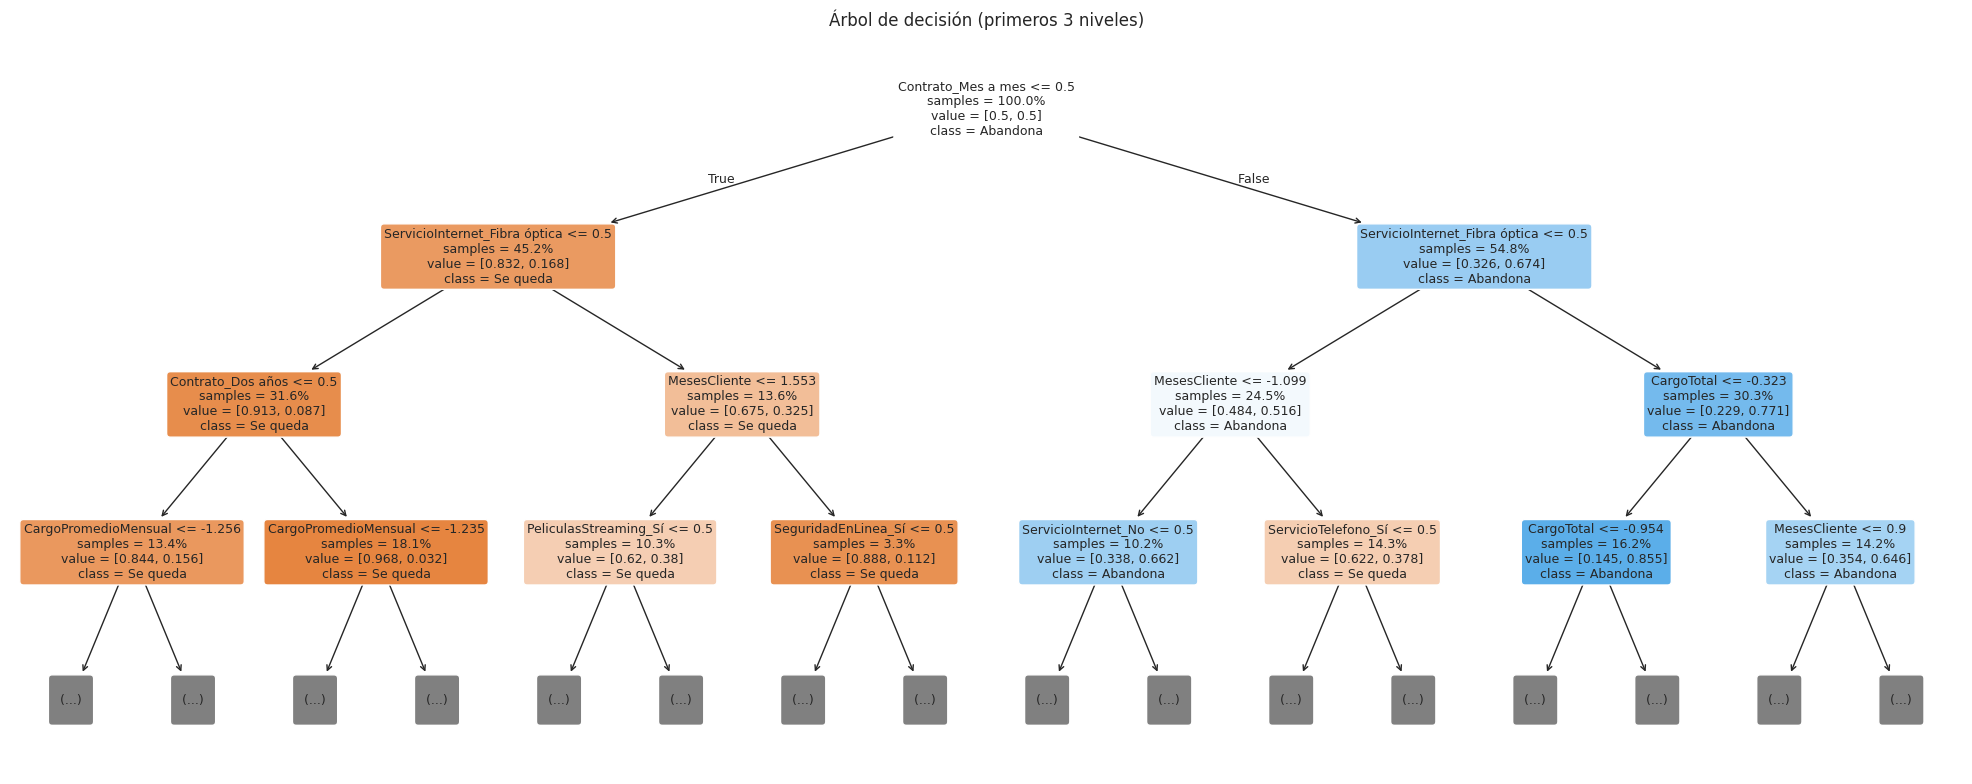

In [ ]:
arbol = pipelines['Árbol de Decisión']
nombres_arbol = [n.replace('num__', '').replace('cat__', '') for n in arbol.named_steps['prep'].get_feature_names_out()]
fig, ax = plt.subplots(figsize=(20, 8))
plot_tree(arbol.named_steps['modelo'], feature_names=nombres_arbol, class_names=['Se queda', 'Abandona'],
          filled=True, rounded=True, max_depth=3, fontsize=9, ax=ax, impurity=False, proportion=True)
ax.set_title('Árbol de decisión (primeros 3 niveles)')
guardar('16_arbol_decision')
plt.show()

El árbol confirma lo que se vio en la exploración: la primera pregunta que hace es si el contrato es mes a mes; después pregunta si el cliente tiene fibra óptica y luego mira la permanencia y el cargo total. (Ojo con los colores de esta figura: `plot_tree` pinta de naranja los nodos donde gana "Se queda" y de azul donde gana "Abandona", al revés que en el resto del cuaderno.) Con estas reglas cualquier persona del área comercial puede entender por qué un cliente sale como riesgoso.

### 7.7 Elección del modelo

Para escoger el mejor modelo me baso en el **recall** y el **F1** de la validación cruzada (que es más confiable que una sola prueba) y en el AUC. El código elige automáticamente el de mayor F1 promedio en validación cruzada y muestra su reporte completo.

In [ ]:
f1_cv = {n: resultados_cv[n]['test_f1'].mean() for n in modelos}
mejor = max(f1_cv, key=f1_cv.get)
print('Modelo elegido:', mejor)
print()
print(classification_report(y_test, pipelines[mejor].predict(X_test), target_names=['Se queda', 'Abandona'], digits=3))

Modelo elegido: Random Forest

              precision    recall  f1-score   support

    Se queda      0.900     0.758     0.823      1033
    Abandona      0.533     0.766     0.628       372

    accuracy                          0.760      1405
   macro avg      0.716     0.762     0.726      1405
weighted avg      0.803     0.760     0.771      1405



## 8. Resultados según la jerarquía DIKW

Para cerrar el análisis organizo los hallazgos según la pirámide Dato → Información → Conocimiento → Sabiduría que trabajamos en las semanas 2 a 4.

In [ ]:
tasa_mm = (df[df['Contrato'] == 'Mes a mes']['Abandono'] == 'Sí').mean() * 100
tasa_2a = (df[df['Contrato'] == 'Dos años']['Abandono'] == 'Sí').mean() * 100
tasa_12 = (df[df['GrupoAntiguedad'] == '0-12']['Abandono'] == 'Sí').mean() * 100
r = tabla_prueba.loc[mejor]
coma = lambda v, d=1: f'{v:.{d}f}'.replace('.', ',')

dikw = pd.DataFrame({
    'Nivel': ['Dato', 'Información', 'Conocimiento', 'Sabiduría'],
    'Pregunta': ['¿Qué tengo?', '¿Qué pasa?', '¿Cómo pasa?', '¿Por qué y qué hago?'],
    'Resultado en este proyecto': [
        f'{len(df_original)} registros y 21 variables de clientes; 11 nulos y 22 duplicados.',
        f'El 26,5 % abandona. Con contrato mes a mes se va el {coma(tasa_mm)} % y con 2 años el {coma(tasa_2a)} %. En el primer año se va el {coma(tasa_12)} %.',
        f'El modelo {mejor} detecta el {r["Recall"]*100:.0f} % de los clientes que se van (AUC {coma(r["AUC-ROC"], 2)}). Las variables clave son contrato, antigüedad, tipo de internet y cargos.',
        'Priorizar la retención en clientes nuevos con contrato mes a mes y fibra óptica: ofrecer pasar a contrato anual, soporte técnico incluido y pago automático.'
    ]
})
pd.set_option('display.max_colwidth', None)
dikw

,Nivel,Pregunta,Resultado en este proyecto
0,Dato,¿Qué tengo?,7043 registros y 21 variables de clientes; 11 nulos y 22 duplicados.
1,Información,¿Qué pasa?,"El 26,5 % abandona. Con contrato mes a mes se va el 42,6 % y con 2 años el 2,8 %. En el primer año se va el 47,4 %."
2,Conocimiento,¿Cómo pasa?,"El modelo Random Forest detecta el 77 % de los clientes que se van (AUC 0,84). Las variables clave son contrato, antigüedad, tipo de internet y cargos."
3,Sabiduría,¿Por qué y qué hago?,"Priorizar la retención en clientes nuevos con contrato mes a mes y fibra óptica: ofrecer pasar a contrato anual, soporte técnico incluido y pago automático."


## 9. Exportación del modelo

Guardo el pipeline completo (preprocesamiento + modelo) con `joblib`. Así el modelo se puede volver a cargar para clasificar clientes nuevos sin entrenarlo otra vez.

In [ ]:
modelo_final = pipelines[mejor]
joblib.dump(modelo_final, 'modelo/modelo_churn.joblib')

info = {
    'modelo': mejor,
    'metricas_prueba': {k: float(v) for k, v in tabla_prueba.loc[mejor].items()},
    'f1_validacion_cruzada': float(f1_cv[mejor]),
    'variables_entrada': list(X.columns),
    'numericas': numericas,
    'categoricas': categoricas,
    'semilla': SEMILLA,
    'registros_entrenamiento': int(len(X_train)),
    'registros_prueba': int(len(X_test)),
}
with open('modelo/info_modelo.json', 'w', encoding='utf-8') as f:
    json.dump(info, f, ensure_ascii=False, indent=2)

tabla_prueba.to_csv('modelo/metricas_prueba.csv')
tabla_cv.to_csv('modelo/metricas_validacion_cruzada.csv')
perfil.to_csv('modelo/perfil_segmentos.csv')
print('Archivos guardados en la carpeta modelo/')
print(json.dumps(info['metricas_prueba'], indent=2))

Archivos guardados en la carpeta modelo/
{
  "Accuracy": 0.7601,
  "Precision": 0.5327,
  "Recall": 0.7661,
  "F1": 0.6284,
  "AUC-ROC": 0.8434
}


### Prueba rápida del modelo guardado

Cargo el archivo y hago una predicción con un cliente inventado, para comprobar que funciona.

In [ ]:
modelo_cargado = joblib.load('modelo/modelo_churn.joblib')
cliente = pd.DataFrame([{
    'Genero': 'Femenino', 'AdultoMayor': 'No', 'Pareja': 'No', 'Dependientes': 'No', 'MesesCliente': 3,
    'ServicioTelefono': 'Sí', 'VariasLineas': 'No', 'ServicioInternet': 'Fibra óptica',
    'SeguridadEnLinea': 'No', 'RespaldoEnLinea': 'No', 'ProteccionEquipo': 'No', 'SoporteTecnico': 'No',
    'TVStreaming': 'Sí', 'PeliculasStreaming': 'No', 'Contrato': 'Mes a mes',
    'FacturaElectronica': 'Sí', 'MetodoPago': 'Cheque electrónico', 'CargoMensual': 85.5, 'CargoTotal': 250.0
}])
cliente = crear_variables(cliente)
prob = modelo_cargado.predict_proba(cliente[X.columns])[0, 1]
print(f'Probabilidad de abandono: {prob*100:.1f} %  ->  {"ABANDONA" if prob >= 0.5 else "SE QUEDA"}')

Probabilidad de abandono: 87.1 %  ->  ABANDONA


## 10. Conclusiones

1. El 26,5 % de los clientes de la empresa abandona el servicio, y ese abandono no es aleatorio: se concentra en clientes con contrato mes a mes, con menos de un año de permanencia, con fibra óptica, que pagan con cheque electrónico y que no tienen soporte técnico ni seguridad en línea.
2. El preprocesamiento fue necesario: había 11 cargos totales vacíos (clientes nuevos, que se completaron con 0), 22 registros duplicados que se eliminaron y categorías repetidas que se unificaron. Las tres variables creadas (número de servicios, cargo promedio mensual y grupo de antigüedad) ayudaron a explicar mejor el comportamiento.
3. PCA y K-Means mostraron que existe un segmento de clientes con un abandono muy por encima del promedio, lo que permite enfocar las acciones de retención.
4. De los tres modelos, el elegido logra detectar a la mayoría de los clientes que se van, con resultados estables en la validación cruzada de 5 particiones. La exactitud por sí sola no sirve en este problema por el desbalance de clases; el recall y el F1 son las métricas que mejor reflejan lo que le interesa a la empresa.
5. El modelo quedó exportado en un archivo `.joblib`, así que puede volver a cargarse para calcular el riesgo de cualquier cliente nuevo